In [13]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
from scipy.stats import rv_histogram

In [2]:
from urllib.request import urlretrieve

In [3]:
urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", "./dr7qso.dat")

('./dr7qso.dat', <http.client.HTTPMessage at 0x7fa61caf78b0>)

In [4]:
z = np.loadtxt("dr7qso.dat", skiprows=80, usecols=3)

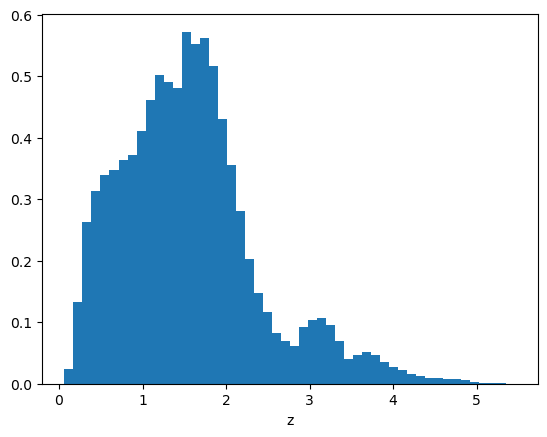

In [22]:
#plt.hist(z)
hist = plt.hist(z,50,density=True)
plt.xlabel('z');

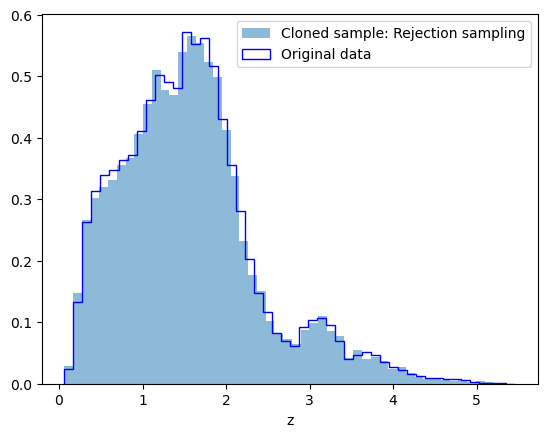

In [37]:
# rejection sampling
N=100000
counts, bins = np.histogram(z,50,density=True)
dist = rv_histogram((counts, bins))


ymax = max(counts)
x = np.random.uniform(0,10,N) #proposed points
y = np.random.uniform(0,ymax,N) #

goodpoints = x[y<=dist.pdf(x)]
plt.hist(goodpoints,50,density=True,alpha=0.5,label='Cloned sample: Rejection sampling')
hist = plt.hist(z,50,density=True,histtype='step',label='Original data', color='b')
plt.xlabel('z')
plt.legend();

In [42]:
from scipy.interpolate import interp1d

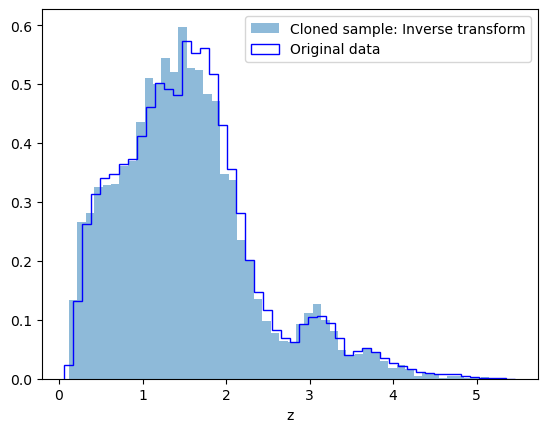

In [46]:
cdf = np.cumsum(counts) / np.sum(counts)
bin_mid = (bins[1:] + bins[:-1]) / 2
cdf_int = interp1d(cdf,bin_mid)

y = np.random.uniform(min(cdf),max(cdf), 10000) 
x_sample = cdf_int(y)

plt.hist(x_sample, bins=50, density=True,label='Cloned sample: Inverse transform',alpha=0.5);
hist = plt.hist(z,50,density=True,histtype='step',label='Original data', color='b')
plt.xlabel('z')
plt.legend();